In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp

In [2]:
# pip install -e .

In [8]:
import pyngauss as ngauss

#### Generating a Gaussian map using a flat power spectrum

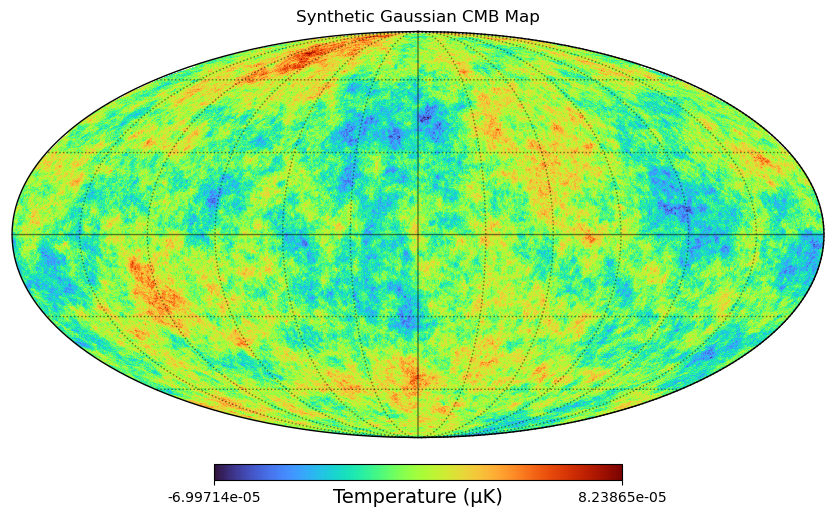

In [9]:
# Parameters for the map
nside = 512  # Map resolution
lmax = 3*nside - 1   # Maximum multipole

# 1. Create a dummy CMB-like power spectrum (C_ell)
ell = np.arange(lmax + 1)
cl = np.zeros_like(ell, dtype=float)

# Simple approximation to give it that "CMB look" (power concentrated at low ell)
cl[2:] = 1e-9 / (ell[2:] * (ell[2:] + 1))**1.2 

# 2. Generate the Gaussian map using synfast
cmb_map = hp.synfast(cl, nside, lmax=lmax, new=True)

# 3. Visualize the raw map
hp.mollview(
    cmb_map, 
    title="Synthetic Gaussian CMB Map", 
    cmap="turbo", 
    unit="Temperature (\u03bcK)"
)
hp.graticule(alpha=0.5)
plt.show()

#### Histogram of the map

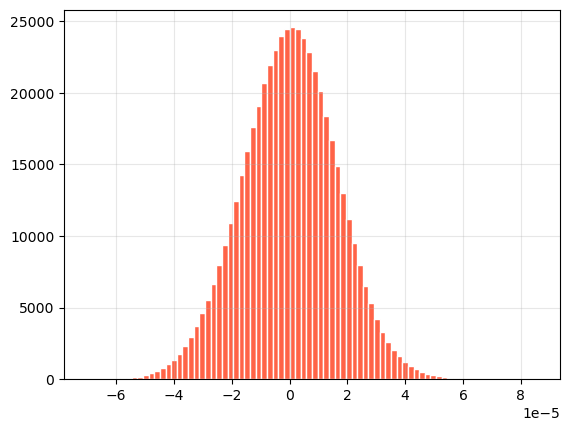

In [10]:
plt.hist(cmb_map, bins=80, density=True,edgecolor='white',color='tomato');
plt.grid(alpha=0.3)

In [11]:
mask=np.ones_like(cmb_map)

#### Compute Three Scalar Minkwoski Functionals

In [12]:
# Compute MFs 
mfs_results = ngauss.compute_mfs(cmb_map,mask)

# Compute SK parameters

sk_results = ngauss.compute_sk_parameters(cmb_map,mask)

print("Computation Complete!")
print(f"SK Parameters: {sk_results}")

Computation Complete!
SK Parameters: (np.float64(1.6421329382688453e-05), np.float64(0.003505500533751612), np.float64(-1242.563590328063), np.float64(502.4280628676239), np.float64(133.75284641376345), np.float64(242765423.7517156), np.float64(-344282.6649332449), np.float64(12812400.972977199), np.float64(2874724.241434147))


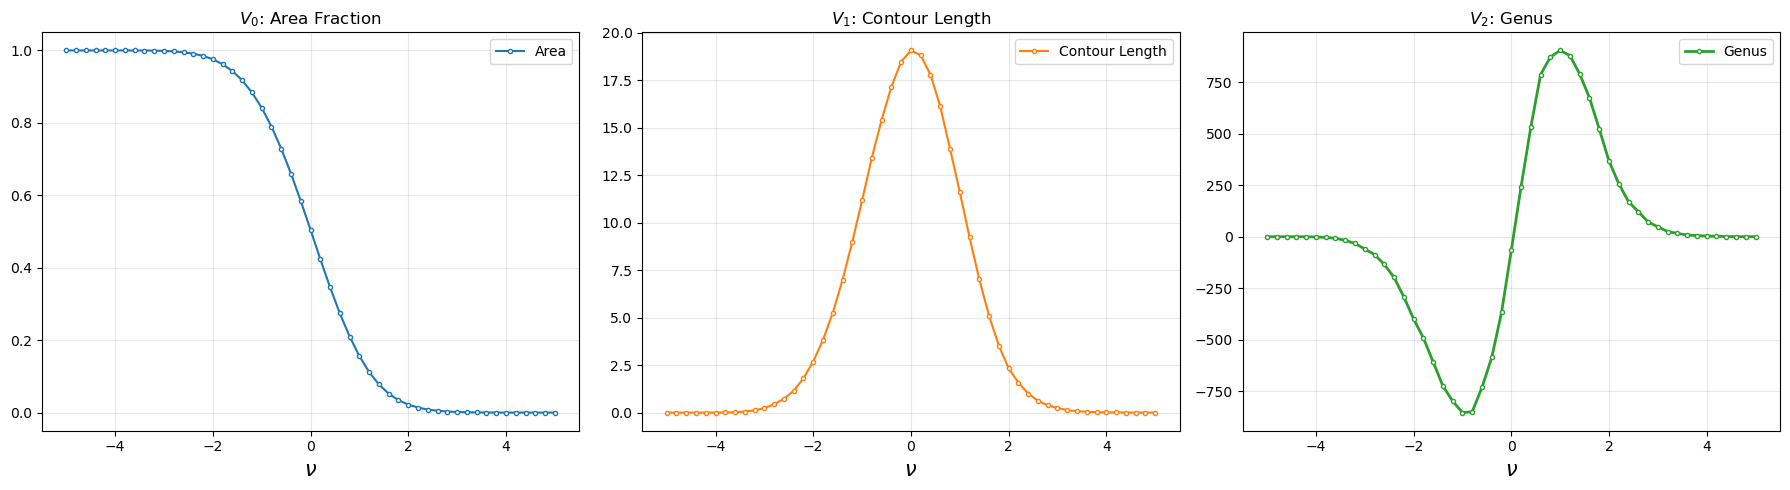

In [13]:
# Extract thresholds and the three MFs 
thresholds = mfs_results[0]
mf0 = mfs_results[1][0]  # Area Fraction
mf1 = mfs_results[1][1]  # Contour Length
mf2 = mfs_results[1][2]  # Genus

# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Area ---
axes[0].plot(thresholds, mf0, label='Area', marker='.', markerfacecolor='white', color='tab:blue')
axes[0].set_title(r'$V_0$: Area Fraction')
axes[0].set_xlabel(r'$\nu$',fontsize=15)
# axes[0].set_ylabel('Amplitude')
axes[0].grid(alpha=0.3)
axes[0].legend()

# --- Plot 2: Contour Length ---
axes[1].plot(thresholds, mf1, label='Contour Length', marker='.', markerfacecolor='white', color='tab:orange')
axes[1].set_title(r'$V_1$: Contour Length')
axes[1].set_xlabel(r'$\nu$',fontsize=15)
axes[1].grid(alpha=0.3)
axes[1].legend()

# --- Plot 3: Genus ---
axes[2].plot(thresholds, mf2, label='Genus', marker='.', markerfacecolor='white', color='tab:green',lw=2)
axes[2].set_title(r'$V_2$: Genus')
axes[2].set_xlabel(r'$\nu$',fontsize=15)
axes[2].grid(alpha=0.3)
axes[2].legend()

# Adjust layout to prevent overlapping labels
plt.tight_layout()
plt.show()

In [14]:
from pyngauss.theory import get_theory_mfs

## Average over 100 maps

In [22]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from tqdm.auto import tqdm 

n_maps = 200
nside = 256
lmax = 3*nside - 1

# Initialize lists
all_mf0, all_mf1, all_mf2 = [], [], []
all_th0, all_th1, all_th2 = [], [], []

for i in tqdm(range(n_maps), desc="Processing Maps"):
    # 1. Generate map
    cmb_map = hp.synfast(cl, nside, lmax=lmax, new=True)
    
    # 2. Compute numerical MFs 
    mfs_results = ngauss.compute_mfs(cmb_map)
    
    # Grab thresholds (assuming compute_mfs uses the same -5 to 5 range)
    thresholds = mfs_results[0]

    # 3. Compute theoretical MFs
    # Your function returns exactly three arrays: v0, v1, v2
    v0, v1, v2 = ngauss.get_theory_mfs(cmb_map)[1:4]  # Assuming it returns (nus, v0, v1, v2)
    
    # 4. Store numerical results
    all_mf0.append(mfs_results[1][0])
    all_mf1.append(mfs_results[1][1])
    all_mf2.append(mfs_results[1][2])
    
    # 5. Store theory results directly!
    all_th0.append(v0)
    all_th1.append(v1)
    all_th2.append(v2)

# --- Process Data ---
all_mf0, all_mf1, all_mf2 = np.array(all_mf0), np.array(all_mf1), np.array(all_mf2)
all_th0, all_th1, all_th2 = np.array(all_th0), np.array(all_th1), np.array(all_th2)

# Averages
avg_mf0 = np.mean(all_mf0, axis=0)
avg_mf1 = np.mean(all_mf1, axis=0)
avg_mf2 = np.mean(all_mf2, axis=0)

avg_th0 = np.mean(all_th0, axis=0)
avg_th1 = np.mean(all_th1, axis=0)
avg_th2 = np.mean(all_th2, axis=0)

# Standard Deviations
std_mf0 = np.std(all_mf0, axis=0)
std_mf1 = np.std(all_mf1, axis=0)
std_mf2 = np.std(all_mf2, axis=0)

print("Ensemble averaging complete!")

Processing Maps: 100%|██████████| 200/200 [00:57<00:00,  3.49it/s]

Ensemble averaging complete!


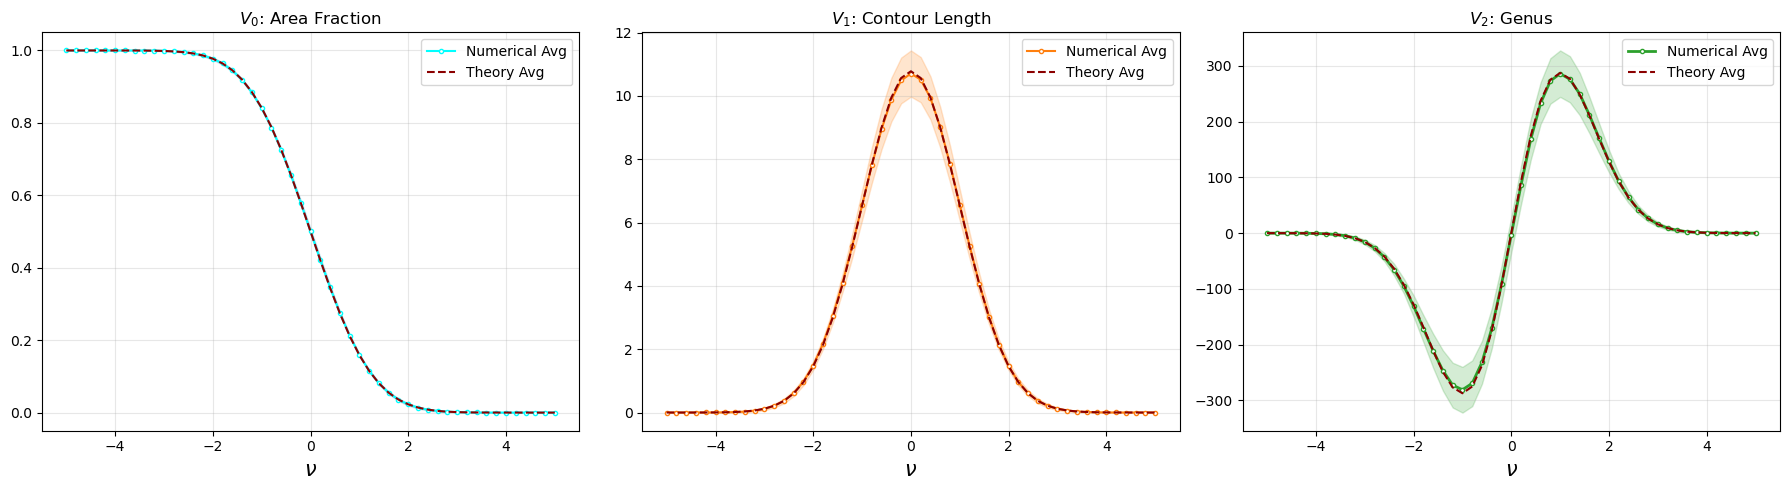

In [23]:
# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Area ---
axes[0].plot(thresholds, avg_mf0, label='Numerical Avg', marker='.', markerfacecolor='white', color='cyan')
axes[0].fill_between(thresholds, avg_mf0 - std_mf0, avg_mf0 + std_mf0, color='tab:blue', alpha=0.2)
axes[0].plot(thresholds, avg_th0, label='Theory Avg', color='darkred', linestyle='--', zorder=4)
axes[0].set_title(r'$V_0$: Area Fraction')
axes[0].set_xlabel(r'$\nu$', fontsize=15)
axes[0].grid(alpha=0.3)
axes[0].legend()

# --- Plot 2: Contour Length ---
axes[1].plot(thresholds, avg_mf1, label='Numerical Avg', marker='.', markerfacecolor='white', color='tab:orange')
axes[1].fill_between(thresholds, avg_mf1 - std_mf1, avg_mf1 + std_mf1, color='tab:orange', alpha=0.2)
axes[1].plot(thresholds, avg_th1, label='Theory Avg', color='darkred', linestyle='--', zorder=4)
axes[1].set_title(r'$V_1$: Contour Length')
axes[1].set_xlabel(r'$\nu$', fontsize=15)
axes[1].grid(alpha=0.3)
axes[1].legend()

# --- Plot 3: Genus ---
axes[2].plot(thresholds, avg_mf2, label='Numerical Avg', marker='.', markerfacecolor='white', color='tab:green', lw=2)
axes[2].fill_between(thresholds, avg_mf2 - std_mf2, avg_mf2 + std_mf2, color='tab:green', alpha=0.2)
axes[2].plot(thresholds, avg_th2, label='Theory Avg', color='darkred', linestyle='--', zorder=4)
axes[2].set_title(r'$V_2$: Genus')
axes[2].set_xlabel(r'$\nu$', fontsize=15)
axes[2].grid(alpha=0.3)
axes[2].legend()

# Adjust layout to prevent overlapping labels
plt.tight_layout()
plt.show()

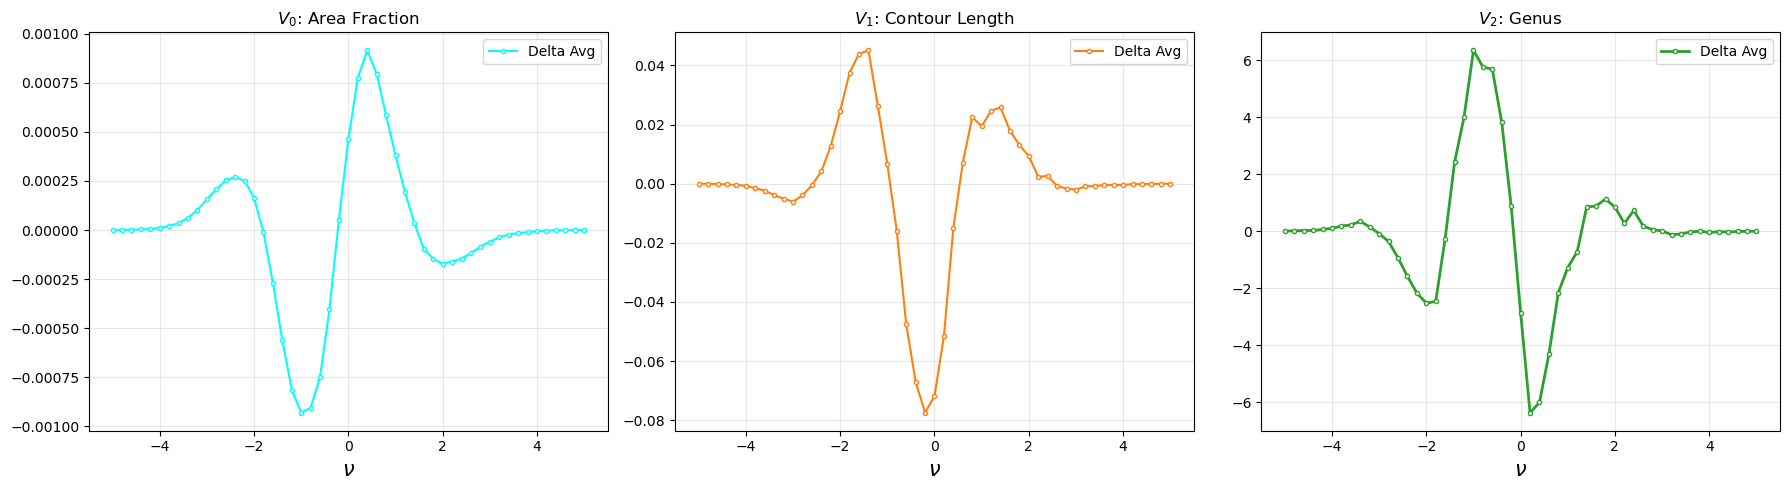

In [24]:
# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Area ---
axes[0].plot(thresholds, avg_mf0-avg_th0, label='Delta Avg', marker='.', markerfacecolor='white', color='cyan')
# axes[0].fill_between(thresholds, avg_mf0 - std_mf0, avg_mf0 + std_mf0, color='tab:blue', alpha=0.2)
# axes[0].plot(thresholds, avg_th0, label='Theory Avg', color='darkred', linestyle='--', zorder=4)
axes[0].set_title(r'$V_0$: Area Fraction')
axes[0].set_xlabel(r'$\nu$', fontsize=15)
axes[0].grid(alpha=0.3)
axes[0].legend()

# --- Plot 2: Contour Length ---
axes[1].plot(thresholds, avg_mf1-avg_th1, label='Delta Avg', marker='.', markerfacecolor='white', color='tab:orange')
# axes[1].fill_between(thresholds, avg_mf1 - std_mf1, avg_mf1 + std_mf1, color='tab:orange', alpha=0.2)
# axes[1].plot(thresholds, avg_th1, label='Theory Avg', color='darkred', linestyle='--', zorder=4)
axes[1].set_title(r'$V_1$: Contour Length')
axes[1].set_xlabel(r'$\nu$', fontsize=15)
axes[1].grid(alpha=0.3)
axes[1].legend()

# --- Plot 3: Genus ---
axes[2].plot(thresholds, avg_mf2-avg_th2, label='Delta Avg', marker='.', markerfacecolor='white', color='tab:green', lw=2)
# axes[2].fill_between(thresholds, avg_mf2 - std_mf2, avg_mf2 + std_mf2, color='tab:green', alpha=0.2)
# axes[2].plot(thresholds, avg_th2, label='Theory Avg', color='darkred', linestyle='--', zorder=4)
axes[2].set_title(r'$V_2$: Genus')
axes[2].set_xlabel(r'$\nu$', fontsize=15)
axes[2].grid(alpha=0.3)
axes[2].legend()

# Adjust layout to prevent overlapping labels
plt.tight_layout()
plt.show()

In [18]:
# import numpy as np
# from pyngauss.sk import compute_sk_parameters
# from scipy.special import erf

# def theory_mfs(map,mask, n_nu=51, nu_min=-5.0, nu_max=5.0, dnu=0.2):
#     """
#     Computes the theoretical Minkowski Functionals for a 2D Gaussian random field.
    
#     Parameters:
#     -----------
#     nu : array-like
#         Normalized thresholds (field value / s0).
#     s0 : float
#         Variance of the field (\sigma_0).
#     s1 : float
#         Variance of the first derivative of the field (\sigma_1).
        
#     Returns:
#     --------
#     tuple : (V0, V1, V2) theoretical curves.
#     """

#     nus = np.linspace(nu_min, nu_max, n_nu)

#     s0,s1=compute_sk_parameters(map,mask)[:2]

#     # V0: Area Fraction
#     v0 = 0.5 * (1.0 - erf(nus / np.sqrt(2.0)))
    
#     # V1: Contour Length
#     v1 = (1.0 / (8.0 * np.sqrt(2.0))) * (s1 / s0) * np.exp(-nus**2 / 2.0)
    
#     # V2: Genus (Euler Characteristic)
#     v2 = (1.0 / (2.0 * (2*np.pi)**1.5)) * (s1 / s0)**2 * nus * np.exp(-nus**2 / 2.0)
    
#     return v0 , v1 , v2 

In [19]:
# from pyngauss.theory import get_theory_mfs